In [14]:
import pandas as pd 
df = pd.read_csv("seattleweather1948-2017_1738467795684.csv")

In [15]:
df.head()

,DATE,PRCP,TMAX,TMIN,RAIN
0,1948-01-01,0.47,51,42,True
1,1948-01-02,0.59,45,36,True
2,1948-01-03,0.42,45,35,True
3,1948-01-04,0.31,45,34,True
4,1948-01-05,0.17,45,32,True


In [16]:
df.isna().sum()

DATE    0
PRCP    3
TMAX    0
TMIN    0
RAIN    3
dtype: int64

In [17]:
df=df.dropna()

In [18]:
df=df.drop("DATE" , axis= 1)

In [19]:
df.head()

,PRCP,TMAX,TMIN,RAIN
0,0.47,51,42,True
1,0.59,45,36,True
2,0.42,45,35,True
3,0.31,45,34,True
4,0.17,45,32,True


In [20]:
def find_outliers(df,col):
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.boxplot(df[col])
    plt.subplot(1,2,2)
    mean4=df[col].mean()
    std4=df[col].std() 
    sns.histplot(data=df , x=col , kde=True)
    plt.axvline(mean4,color="red")
    plt.axvline(mean4+3*std4 , color = "blue")
    plt.axvline(mean4-3*std4 , color="blue")

In [24]:
def show_outliers(df,col):
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr = q3-q1
    upper = q3+(1.5*iqr)
    lower=q1-(1.5*iqr)
    return df[(df[col]<lower) | (df[col]>upper)]
    

In [27]:
def handleOutliers(df,col):
    q1=df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr=q3-q1
    lower = q1-(1.5*iqr)
    upper = q3+(1.5*iqr)
    df.loc[df[col]>upper , col]=upper
    df.loc[df[col]<lower , col]=lower

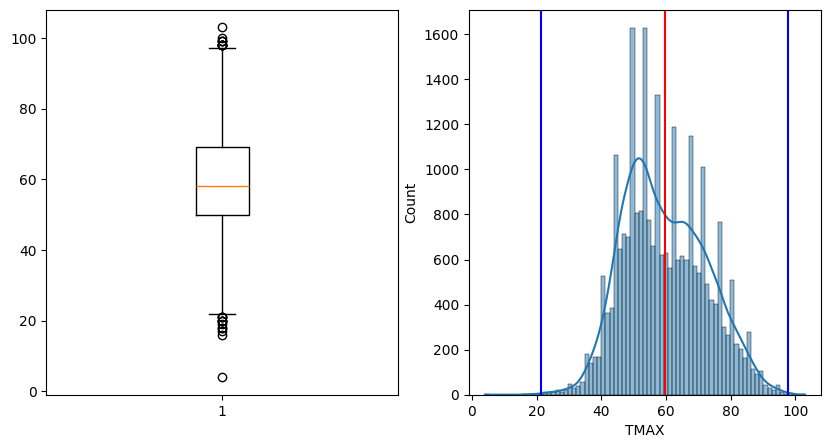

In [25]:
import matplotlib.pyplot as plt 
import seaborn as sns 
find_outliers(df,"TMAX")


In [26]:
show_outliers(df,"TMAX")

,PRCP,TMAX,TMIN,RAIN
743,1.27,19,11,True
744,0.16,16,8,True
745,0.02,21,15,True
761,0.00,20,0,False
1419,0.08,4,39,True
2872,0.00,21,13,False
4603,0.00,98,66,False
4604,0.00,99,59,False
6194,0.00,20,10,False
7167,0.00,98,59,False


In [28]:
handleOutliers(df,"TMAX")

C:\Users\Admin\AppData\Local\Temp\ipykernel_7008\518119364.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '97.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[col]>upper , col]=upper


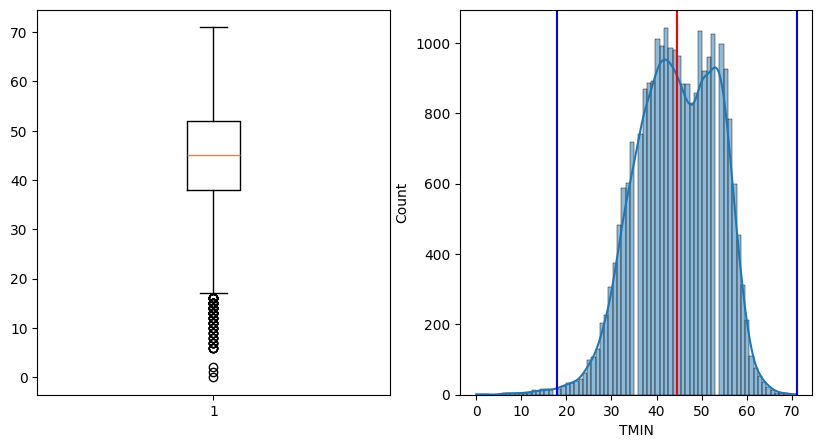

In [31]:
find_outliers(df,"TMIN")

In [32]:
show_outliers(df,"TMIN")

,PRCP,TMAX,TMIN,RAIN
358,0.00,36.0,16,False
374,0.00,32.0,13,False
375,0.00,30.0,12,False
388,0.00,30.0,16,False
393,0.00,41.0,16,False
...,...,...,...,...
18618,0.00,29.0,16,False
22269,0.16,26.0,14,True
22624,0.00,36.0,16,False
22972,0.00,25.0,16,False


In [33]:
handleOutliers(df,"TMIN")

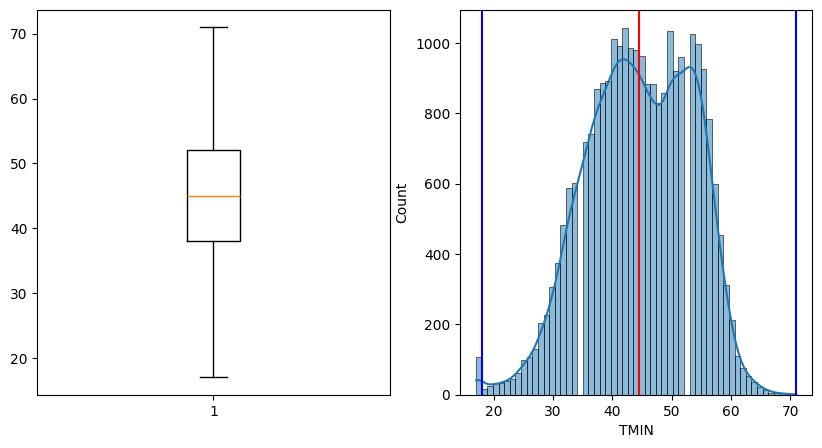

In [35]:
find_outliers(df,"TMIN")

In [36]:
x = df.drop(["RAIN"],axis=1)
y=df["RAIN"]

In [37]:
x

,PRCP,TMAX,TMIN
0,0.47,51.0,42
1,0.59,45.0,36
2,0.42,45.0,35
3,0.31,45.0,34
4,0.17,45.0,32
...,...,...,...
25546,0.00,49.0,34
25547,0.00,49.0,29
25548,0.00,46.0,32
25549,0.00,48.0,34


In [38]:
df.describe()

,PRCP,TMAX,TMIN
count,25548.000000,25548.000000,25548.000000
mean,0.106222,59.544191,44.530726
std,0.239031,12.765594,8.831772
min,0.000000,21.500000,17.000000
25%,0.000000,50.000000,38.000000
50%,0.000000,58.000000,45.000000
75%,0.100000,69.000000,52.000000
max,5.020000,97.500000,71.000000


In [44]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
x_ss = ss.fit_transform(x)


In [45]:
y

0         True
1         True
2         True
3         True
4         True
         ...  
25546    False
25547    False
25548    False
25549    False
25550    False
Name: RAIN, Length: 25548, dtype: object

In [54]:
df["RAIN"].value_counts()

RAIN
False    14648
True     10900
Name: count, dtype: int64

In [48]:
print(y.unique())
print(y.dtype)

[True False]
object


PRCP    0
TMAX    0
TMIN    0
RAIN    0
dtype: int64

In [53]:
from imblearn.over_sampling import SMOTE

# Fix y
y = y.astype(int)
y = y.ravel()

# Apply SMOTE
sm = SMOTE()
x_sm, y_sm = sm.fit_resample(x_ss, y)


C:\Users\Admin\AppData\Local\Temp\ipykernel_7008\2838227496.py:5: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y = y.ravel()


In [60]:
y_sm.value_counts()

AttributeError: 'numpy.ndarray' object has no attribute 'value_counts'

In [56]:
df["RAIN"].unique()

array([True, False], dtype=object)

In [58]:
df["RAIN"] = df["RAIN"].replace({"True" :1, "False":0})

C:\Users\Admin\AppData\Local\Temp\ipykernel_7008\3841868803.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["RAIN"] = df["RAIN"].replace({"True" :1, "False":0})


In [61]:
from sklearn.model_selection import train_test_split
x_train,x_test , y_train,y_test = train_test_split(x_ss,y,test_size=0.2,random_state=37)

In [62]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [63]:
test_pred = model.predict(x_test)

In [64]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,test_pred)

0.9681017612524462

In [65]:
model.predict([[0.0 , 60,50]])

array([0])

In [66]:
model.predict_proba([[0.0,60,50]])

array([[1.00000000e+00, 9.42964552e-11]])